# Biểu diễn văn bản thành đồ thị (TextRank Graph Visualization)

- **Node** = câu trong văn bản
- **Cạnh** = Cosine TF-IDF Similarity giữa 2 câu
- **Kích thước node** = điểm PageRank

In [17]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Các hàm TextRank (từ vector.py và textrank.py)

In [18]:
def build_tfidf_matrix(sentences):
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1
    )
    tfidf_matrix = vectorizer.fit_transform(sentences)
    return tfidf_matrix, vectorizer


def calculate_similarity_matrix(tfidf_matrix):
    sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    np.fill_diagonal(sim_matrix, 0)
    return sim_matrix


def build_stochastic_matrix(sim_matrix):
    n = sim_matrix.shape[0]
    row_sums = sim_matrix.sum(axis=1)
    dangling = row_sums == 0
    stochastic_matrix = np.zeros_like(sim_matrix, dtype=float)
    if np.any(~dangling):
        stochastic_matrix[~dangling] = (
            sim_matrix[~dangling] / row_sums[~dangling][:, np.newaxis]
        )
    if np.any(dangling):
        stochastic_matrix[dangling] = 1.0 / n
    return stochastic_matrix.T


def calculate_pagerank_numpy(sim_matrix, damping_factor=0.85, max_iter=100, tol=1e-6):
    n = sim_matrix.shape[0]
    if n == 0:
        return {}
    M = build_stochastic_matrix(sim_matrix)
    scores = np.full(n, 1.0 / n)
    damping_vector = np.full(n, (1.0 - damping_factor) / n)
    for _ in range(max_iter):
        prev_scores = scores.copy()
        scores = damping_factor * np.dot(M, prev_scores) + damping_vector
        if np.linalg.norm(scores - prev_scores, ord=1) < tol:
            break
    return {i: score for i, score in enumerate(scores)}


def split_sentences(text):
    pattern = r"<s[^>]*>(.*?)</s>"
    sentences = re.findall(pattern, text, flags=re.DOTALL)
    return [re.sub(r"\s+", " ", s).strip() for s in sentences]

## 2. Đọc dữ liệu và tách câu

In [19]:
import os

cwd = os.getcwd()
print(f"Thư mục hiện tại: {cwd}")


if os.path.isdir(os.path.join(cwd, "data", "DUC_TEXT")):
    BASE_DIR = cwd                                                
elif os.path.isdir(os.path.join(cwd, "..", "data", "DUC_TEXT")):
    BASE_DIR = os.path.abspath(os.path.join(cwd, ".."))          
elif os.path.isdir(os.path.join(cwd, "Project(NLP)", "data", "DUC_TEXT")):
    BASE_DIR = os.path.join(cwd, "Project(NLP)")               
else:
    raise FileNotFoundError(f"Không tìm thấy data/DUC_TEXT từ thư mục: {cwd}")

print(f"BASE_DIR: {BASE_DIR}")

sample_file = os.path.join(BASE_DIR, "data", "DUC_TEXT", "train", "d061j")
print(f"Đọc file: {sample_file}")

with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

sentences = split_sentences(text)
print(f"Tổng số câu: {len(sentences)}")

N = 20
sents = sentences[:N]

Thư mục hiện tại: /Users/huyhd/Huy Form/Project(NLP)/notebook
BASE_DIR: /Users/huyhd/Huy Form/Project(NLP)
Đọc file: /Users/huyhd/Huy Form/Project(NLP)/data/DUC_TEXT/train/d061j
Tổng số câu: 186


## 3. Xây dựng đồ thị

- Tính ma trận TF-IDF
- Tính Cosine Similarity giữa các cặp câu
- Chạy PageRank

In [20]:
# TF-IDF
tfidf_matrix, _ = build_tfidf_matrix(sents)
print("\n" + "=" * 60)
print("TF-IDF")
print("=" * 60)

print(f"Shape : {tfidf_matrix.shape}")
print(f"Nodes : {tfidf_matrix.shape[0]}")
print(f"Features : {tfidf_matrix.shape[1]}")

# Cosine Similarity
sim_matrix = calculate_similarity_matrix(tfidf_matrix)

print("\n" + "=" * 60)
print("COSINE SIMILARITY")
print("=" * 60)

print(f"Shape : {sim_matrix.shape}")
print(f"Min   : {sim_matrix.min():.4f}")
print(f"Max   : {sim_matrix.max():.4f}")
print(f"Mean  : {sim_matrix.mean():.4f}")

# PageRank
scores = calculate_pagerank_numpy(sim_matrix)

print("\n" + "=" * 60)
print("PAGERANK")
print("=" * 60)

ranking = sorted(
    scores.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Top 5 sentences:")

for rank, (idx, score) in enumerate(ranking[:5], 1):
    print(f"  {rank}. Sentence {idx + 1:<2} → {score:.6f}")

# Graph
threshold = 0.05
num_edges = np.sum(np.triu(sim_matrix > threshold, k=1))

print("\n" + "=" * 60)
print("GRAPH")
print("=" * 60)

print(f"Nodes     : {len(sents)}")
print(f"Threshold : {threshold}")
print(f"Edges     : {num_edges}")


TF-IDF
Shape : (20, 352)
Nodes : 20
Features : 352

COSINE SIMILARITY
Shape : (20, 20)
Min   : 0.0000
Max   : 0.7327
Mean  : 0.0240

PAGERANK
Top 5 sentences:
  1. Sentence 8  → 0.085196
  2. Sentence 7  → 0.072745
  3. Sentence 17 → 0.072204
  4. Sentence 1  → 0.070607
  5. Sentence 6  → 0.060215

GRAPH
Nodes     : 20
Threshold : 0.05
Edges     : 32


## 4. Vẽ đồ thị câu + Ma trận Cosine Similarity

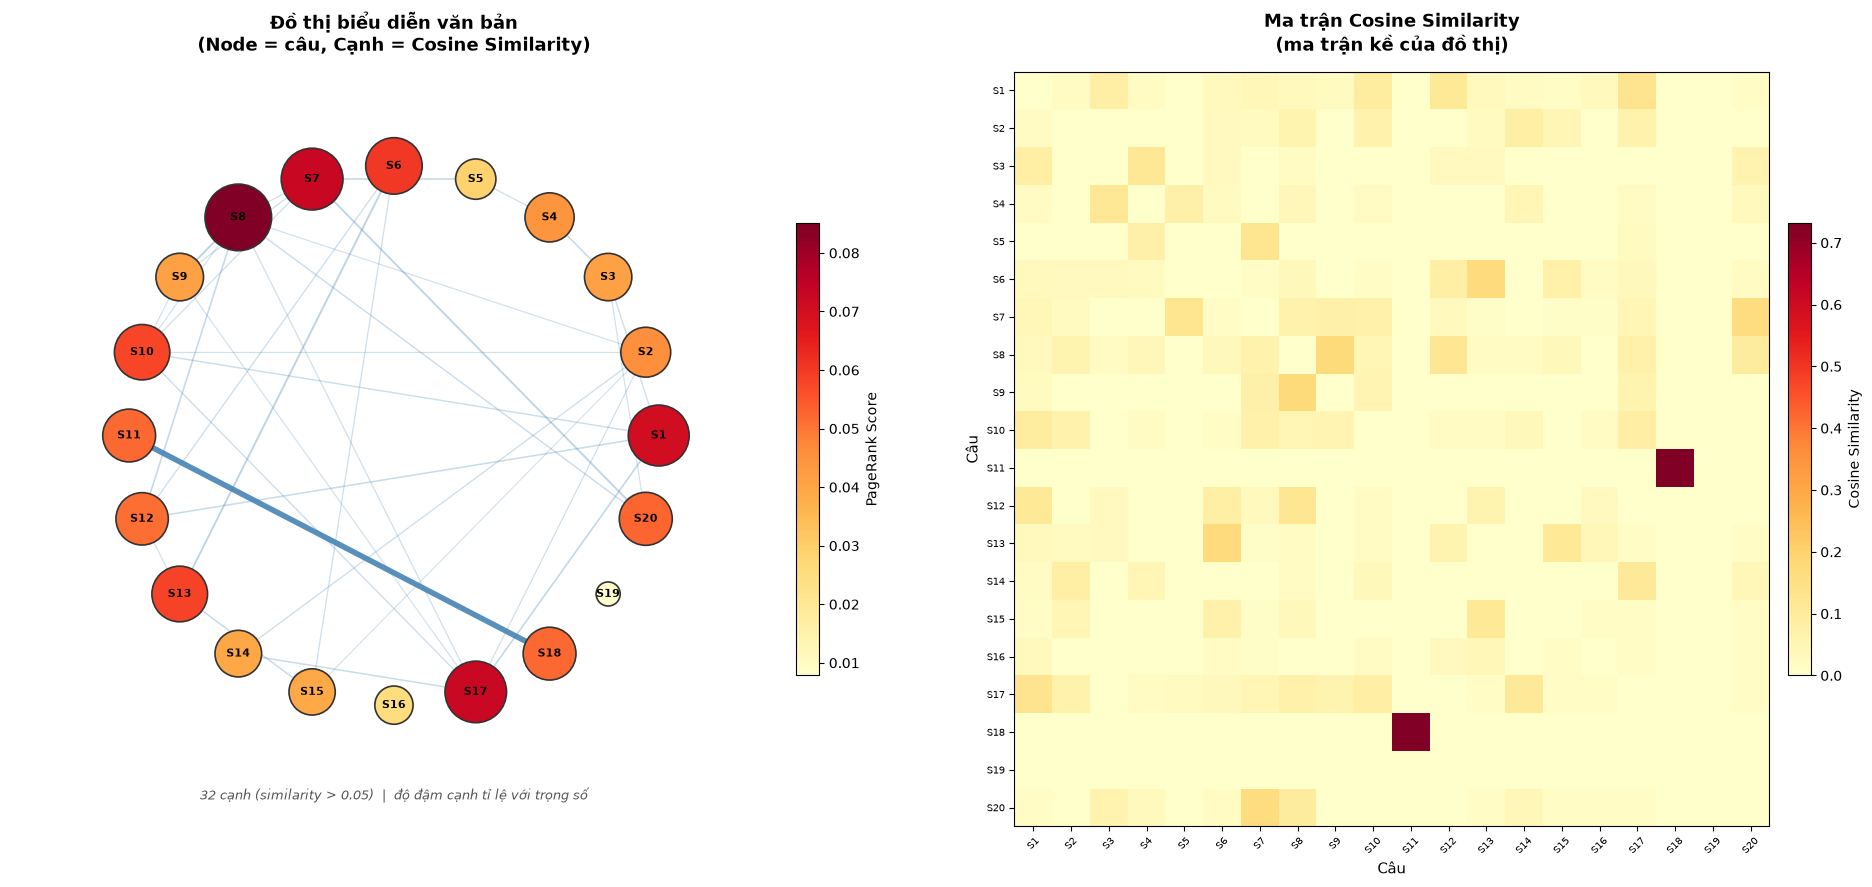

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# === HÌNH 1: Đồ thị câu ===
ax1 = axes[0]
ax1.set_title("Đồ thị biểu diễn văn bản\n(Node = câu, Cạnh = Cosine Similarity)",
              fontsize=13, fontweight='bold', pad=15)

# Vị trí các node theo hình tròn
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
x_pos = np.cos(angles)
y_pos = np.sin(angles)

# Vẽ cạnh — độ đậm/dày tỉ lệ với trọng số CHUẨN HOÁ theo cạnh mạnh nhất,
# vì trọng số cosine tuyệt đối rất nhỏ (~0.03) nên nếu vẽ theo giá trị thô
# thì gần như toàn bộ cạnh sẽ mờ tới mức không nhìn thấy.
w_max = sim_matrix.max() if sim_matrix.max() > 0 else 1.0

for i in range(N):
    for j in range(i + 1, N):
        w = sim_matrix[i][j]
        if w > threshold:
            rel = w / w_max                      # chuẩn hoá về [0, 1]
            ax1.plot([x_pos[i], x_pos[j]], [y_pos[i], y_pos[j]],
                     color='steelblue',
                     alpha=0.18 + 0.72 * rel,
                     linewidth=0.6 + 3.4 * rel,
                     zorder=1)

# Vẽ node (kích thước theo PageRank)
node_scores = [scores[i] for i in range(N)]
min_s, max_s = min(node_scores), max(node_scores)
node_sizes = [300 + 2000 * (s - min_s) / (max_s - min_s + 1e-9) for s in node_scores]

scatter = ax1.scatter(x_pos, y_pos, s=node_sizes, c=node_scores,
                      cmap=plt.cm.YlOrRd, edgecolors='#333', linewidths=1.2, zorder=5)

for i in range(N):
    ax1.text(x_pos[i], y_pos[i], f"S{i+1}", ha='center', va='center',
             fontsize=8, fontweight='bold', zorder=6)

cbar = plt.colorbar(scatter, ax=ax1, shrink=0.6, pad=0.02)
cbar.set_label('PageRank Score', fontsize=10)
ax1.text(0, -1.35, f"{num_edges} cạnh (similarity > {threshold})  |  "
                   f"độ đậm cạnh tỉ lệ với trọng số",
         ha='center', fontsize=9, style='italic', color='#555')
ax1.set_xlim(-1.45, 1.45); ax1.set_ylim(-1.45, 1.35)
ax1.set_axis_off()

# === HÌNH 2: Ma trận Similarity (Heatmap) ===
ax2 = axes[1]
ax2.set_title("Ma trận Cosine Similarity\n(ma trận kề của đồ thị)",
              fontsize=13, fontweight='bold', pad=15)

im = ax2.imshow(sim_matrix[:N, :N], cmap='YlOrRd', aspect='equal')
ax2.set_xlabel("Câu", fontsize=11)
ax2.set_ylabel("Câu", fontsize=11)
ax2.set_xticks(range(N))
ax2.set_yticks(range(N))
ax2.set_xticklabels([f"S{i+1}" for i in range(N)], fontsize=7, rotation=45)
ax2.set_yticklabels([f"S{i+1}" for i in range(N)], fontsize=7)

cbar2 = plt.colorbar(im, ax=ax2, shrink=0.6, pad=0.02)
cbar2.set_label('Cosine Similarity', fontsize=10)

plt.tight_layout(pad=3)
plt.show()

## 5. Điểm PageRank của các câu (Bar Chart)

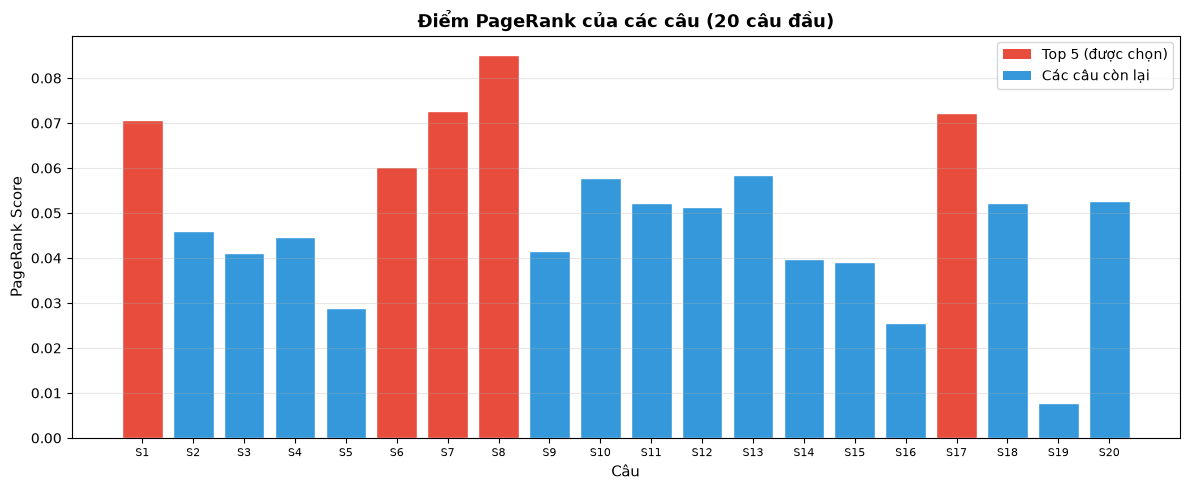

In [22]:
fig2, ax3 = plt.subplots(figsize=(12, 5))
ax3.set_title("Điểm PageRank của các câu (20 câu đầu)", fontsize=13, fontweight='bold')

colors = ['#e74c3c' if scores[i] >= sorted(scores.values(), reverse=True)[4]
          else '#3498db' for i in range(len(sents))]
bars = ax3.bar(range(len(sents)), [scores[i] for i in range(len(sents))], color=colors, edgecolor='white')

ax3.set_xlabel("Câu", fontsize=11)
ax3.set_ylabel("PageRank Score", fontsize=11)
ax3.set_xticks(range(len(sents)))
ax3.set_xticklabels([f"S{i+1}" for i in range(len(sents))], fontsize=8)

legend_elements = [Patch(facecolor='#e74c3c', label='Top 5 (được chọn)'),
                   Patch(facecolor='#3498db', label='Các câu còn lại')]
ax3.legend(handles=legend_elements, fontsize=10)

ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Top 5 câu có PageRank cao nhất

In [23]:
print("--- TOP 5 CÂU PAGERANK CAO NHẤT ---")
ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
for idx, (i, score) in enumerate(ranked[:5]):
    print(f"  {idx+1}. S{i+1} (score={score:.4f}): {sents[i][:80]}...")

--- TOP 5 CÂU PAGERANK CAO NHẤT ---
  1. S8 (score=0.0852): The National Weather Service in San Juan, Puerto Rico, said Gilbert was moving w...
  2. S7 (score=0.0727): The National Hurricane Center in Miami reported its position at 2 a.m. Sunday at...
  3. S17 (score=0.0722): Hurricane Gilbert, packing 110 mph winds and torrential rain, moved over this ca...
  4. S1 (score=0.0706): Hurricane Gilbert swept toward the Dominican Republic Sunday, and the Civil Defe...
  5. S6 (score=0.0602): Tropical Storm Gilbert formed in the eastern Caribbean and strengthened into a h...


## 7. Kiểm chứng với `output/d061j_summary.txt`

Các mục trên chỉ chạy trên **20 câu đầu** nên không so được với file output.
Mục này chạy lại pipeline trên **toàn bộ 186 câu** của `d061j`, lấy **top 18 câu điểm PageRank cao nhất**
(**xếp theo điểm giảm dần, không sắp lại theo thứ tự gốc**), rồi so với `output/d061j_summary.txt`.

Vì file output do `src/main.py` ghi theo **thứ tự xuất hiện trong văn bản**, còn ở đây xếp theo **điểm**,
nên so sánh theo **tập hợp câu** (cùng 18 câu hay không), không so theo từng dòng.

In [30]:
import os

_cwd = os.getcwd()
if os.path.isdir(os.path.join(_cwd, "data", "DUC_TEXT")):
    BASE_DIR = _cwd
elif os.path.isdir(os.path.join(_cwd, "..", "data", "DUC_TEXT")):
    BASE_DIR = os.path.abspath(os.path.join(_cwd, ".."))
elif os.path.isdir(os.path.join(_cwd, "Project(NLP)", "data", "DUC_TEXT")):
    BASE_DIR = os.path.join(_cwd, "Project(NLP)")
else:
    raise FileNotFoundError(f"Không tìm thấy data/DUC_TEXT từ: {_cwd}")

DOC_ID = "d061j"
TOP_N = 18

# Đọc file d061j và tách câu
doc_path = os.path.join(BASE_DIR, "data", "DUC_TEXT", "train", DOC_ID)
with open(doc_path, "r", encoding="utf-8", errors="ignore") as f:
    doc_sentences = split_sentences(f.read())

# TF-IDF -> Cosine -> PageRank trên full câu
full_tfidf, _ = build_tfidf_matrix(doc_sentences)
full_sim = calculate_similarity_matrix(full_tfidf)
full_scores = calculate_pagerank_numpy(full_sim)

# Top 18 câu điểm cao nhất , ko sắp xếp
ranked_full = sorted(full_scores.items(), key=lambda x: x[1], reverse=True)
top_ranked = ranked_full[:TOP_N]
my_lines = [doc_sentences[i] for i, _ in top_ranked]

# Đọc file output do src/main.py sinh ra
summary_path = os.path.join(BASE_DIR, "output", f"{DOC_ID}_summary.txt")
with open(summary_path, "r", encoding="utf-8") as f:
    file_lines = f.read().strip().splitlines()

# Liệt kê song song: notebook (theo điểm)  vs  file (theo văn bản)
def sidx(line):
    #Tìm chỉ số câu trong doc_sentences (dạng S<n>).
    try:
        return f"S{doc_sentences.index(line) + 1}"
    except ValueError:
        return "S?"

W = 62
print(f"{'#':>2}  {'NOTEBOOK (xếp theo điểm giảm dần)':<{W}}  FILE (xếp theo thứ tự văn bản)")
print("-" * (6 + W + 3 + W))
for k in range(max(len(my_lines), len(file_lines))):
    if k < len(my_lines):
        i, sc = top_ranked[k]
        left = f"{sidx(my_lines[k]):<4} {sc:.4f} {my_lines[k]}"
    else:
        left = ""
    right = f"{sidx(file_lines[k])} {file_lines[k]}" if k < len(file_lines) else ""
    mark = "=" if (k < len(my_lines) and k < len(file_lines) and my_lines[k] == file_lines[k]) else " "
    print(f"{k + 1:>2} {mark} {left[:W]:<{W}}  {right[:W]}")

# So theo TẬP HỢP câu (bỏ qua thứ tự)
mine_set, file_set = set(my_lines), set(file_lines)
print("\n" + "=" * 72)
print(f">>> CÙNG TẬP {TOP_N} CÂU? {mine_set == file_set}   "
      f"(notebook {len(mine_set)} câu / file {len(file_set)} câu phân biệt)")

only_mine = mine_set - file_set
only_file = file_set - mine_set
if only_mine:
    print(f"\nChỉ có ở notebook ({len(only_mine)}):")
    for s in only_mine:
        print(f"  - {s[:90]}")
if only_file:
    print(f"\nChỉ có ở file ({len(only_file)}):")
    for s in only_file:
        print(f"  - {s[:90]}")


 #  NOTEBOOK (xếp theo điểm giảm dần)                               FILE (xếp theo thứ tự văn bản)
-------------------------------------------------------------------------------------------------------------------------------------
 1 = S58  0.0112 A National Weather Service report said the hurrica  S58 A National Weather Service report said the hurricane was m
 2 = S17  0.0107 Hurricane Gilbert, packing 110 mph winds and torre  S17 Hurricane Gilbert, packing 110 mph winds and torrential ra
 3 = S128 0.0105 The National Hurricane Center said Gilbert was the  S128 The National Hurricane Center said Gilbert was the most i
 4 = S20  0.0103 ``Right now it's actually moving over Jamaica,'' s  S20 ``Right now it's actually moving over Jamaica,'' said Bob 
 5 = S20  0.0103 ``Right now it's actually moving over Jamaica,'' s  S20 ``Right now it's actually moving over Jamaica,'' said Bob 
 6 = S173 0.0103 Forecasters said the hurricane was gaining strengt  S173 Forecasters said the hurricane wa